# UN Calibration — Clean Reference Notebook

Minimal, fast notebook that loads the **v14 rank-1 winning candidate** from the
Optuna study CSV and reruns the full M7/capture_only model at that parameter
set, then plots model output against Rizk (2025) experimental anchors.

**Why this notebook exists**: `UNmodel.ipynb`, `UNpython_tests.ipynb` and
`UN_Barani_model.ipynb` each redefine the full ~1500-line model inline, run
sequential sweeps, and mix exploration with results. This notebook:

- imports the M7 / capture_only model from `../optuna/UN_M7_optuna_calibration_v8_core.py`
- loads the v14 rank-1 candidate via `candidate_from_score_row` from the same module
- parallelises temperature sweeps via `joblib`
- shows only curated plots (model vs Rizk Fig. 3 / 7 / 8 / 9)

The vectorised `un_model_fast` (in `../model/`) is a simpler 3-equation baseline
used for development and parity testing — it does not expose the granular scaling
factors (`gb_scale`, `gd_bubble_scale`, `coalescence_d_scale`, …) that v14 fits,
so it cannot reproduce v14's strong N_d drop. Hence this notebook uses `v8_core`.

**Sections**

1. Imports + load v14 rank-1 candidate
2. Smoke test at the v14 candidate
3. Swelling vs T (Rizk Fig. 3, three burnups)
4. R_d, N_d vs T at 1.3 % FIMA (Rizk Fig. 7 / 8) — should now show the dramatic N_d drop
5. Gas partition vs T (Rizk Fig. 9 style)
6. v14 best-candidate table


## 1. Imports and v14 candidate


In [1]:
import sys, pathlib
# Notebook lives in un_calibration/notebooks/. Find un_calibration/ root.
_HERE = pathlib.Path.cwd().resolve()
while _HERE.name != "un_calibration" and _HERE.parent != _HERE:
    _HERE = _HERE.parent
sys.path.insert(0, str(_HERE / "model"))
sys.path.insert(0, str(_HERE / "optuna"))

import un_data
import UN_M7_optuna_calibration_v8_core as m

import numpy as np
import matplotlib.pyplot as plt
from joblib import Parallel, delayed
import pandas as pd

print(f"Loaded model: {m.__name__}  (M7 / capture_only family)")


Loaded model: UN_M7_optuna_calibration_v8_core  (M7 / capture_only family)


In [2]:
# Load top candidate from v14 results CSV
csv_path = _HERE / "results" / "UN_M7_optuna_v14_rhoSat_qgbStrict_NdAnchors_results" / "capture_only" / "optuna_final_top_capture_only.csv"
if not csv_path.exists():
    raise FileNotFoundError(f"v14 results not found at {csv_path}.\n"
                            "Generate via: bash un_calibration/runners/run_v14_rhoSat_qgbStrict_NdAnchors_block.sh 100")

df = pd.read_csv(csv_path).sort_values('score_total').reset_index(drop=True)
row = df.iloc[0].to_dict()
cand = m.candidate_from_score_row(row, label_prefix="v14_rank1")

print(f"v14 rank-1 candidate: {row['label']}")
print(f"  score_total = {row['score_total']:.3f}")
print(f"  f_n         = {cand.f_n:.2e}")
print(f"  K_d         = {cand.K_d:.2e}")
print(f"  rho_d       = {cand.rho_d:.2e}")
print(f"  fission_rate= {cand.fission_rate:.2e}")
print(f"  scaling factors:")
print(f"    gb_scale            = {cand.gb_scale:.3f}")
print(f"    gd_bubble_scale     = {cand.gd_bubble_scale:.3f}")
print(f"    gd_line_scale       = {cand.gd_line_scale:.3f}")
print(f"    b_bulk_scale        = {cand.b_bulk_scale:.3f}")
print(f"    b_dislocation_scale = {cand.b_dislocation_scale:.3f}")
print(f"    coalescence_d_scale = {cand.coalescence_d_scale:.3f}")
print(f"    capture_scale       = {cand.capture_scale:.3f}")


v14 rank-1 candidate: FINAL_rank1_capture_only_capture_only_v13_trial_00066
  score_total = 2.351
  f_n         = 1.81e-07
  K_d         = 3.53e+05
  rho_d       = 3.00e+13
  fission_rate= 7.03e+19
  scaling factors:
    gb_scale            = 1.652
    gd_bubble_scale     = 0.094
    gd_line_scale       = 5.457
    b_bulk_scale        = 0.243
    b_dislocation_scale = 0.115
    coalescence_d_scale = 0.984
    capture_scale       = 0.247


## 2. Smoke test at the v14 candidate (T=1600 K, 1.3 % FIMA)


In [3]:
DT_H = 12.0     # FAST integration timestep
N_MODES = 25    # FAST spectral truncation

out = m.run_model_point(1600.0, 1.3, cand, DT_H, N_MODES, keep_history=False)
print(f"Single-point run (M7 / capture_only, v14 rank-1 candidate):")
print(f"  T = 1600 K, 1.3 % FIMA, dt_h={DT_H}, n_modes={N_MODES}")
print(f"  swelling (dislocation) = {out['swelling_d_percent']:.3f} %")
print(f"  swelling (bulk)        = {out['swelling_b_percent']:.3f} %")
print(f"  R_d                    = {out['Rd_nm']:.1f} nm")
print(f"  R_b                    = {out['Rb_nm']:.1f} nm")
print(f"  N_d                    = {out['Nd']:.2e} m^-3")
print(f"  Gas partition: matrix={out['matrix_gas_percent']:.1f}%  bulk={out['bulk_gas_percent']:.1f}%  "
      f"disl={out['dislocation_gas_percent']:.1f}%  q_gb={out['qgb_gas_percent']:.1f}%")


Single-point run (M7 / capture_only, v14 rank-1 candidate):
  T = 1600 K, 1.3 % FIMA, dt_h=12.0, n_modes=25
  swelling (dislocation) = 3.723 %
  swelling (bulk)        = 0.175 %
  R_d                    = 99.2 nm
  R_b                    = 11.1 nm
  N_d                    = 9.10e+18 m^-3
  Gas partition: matrix=0.4%  bulk=8.4%  disl=87.6%  q_gb=3.6%


## 3. Swelling vs T (Rizk Fig. 3)

Model curves overlaid on Rizk Fig. 3 experimental anchors at 1.1 / 1.3 / 3.2 % FIMA.
Sweep parallelised across temperatures.


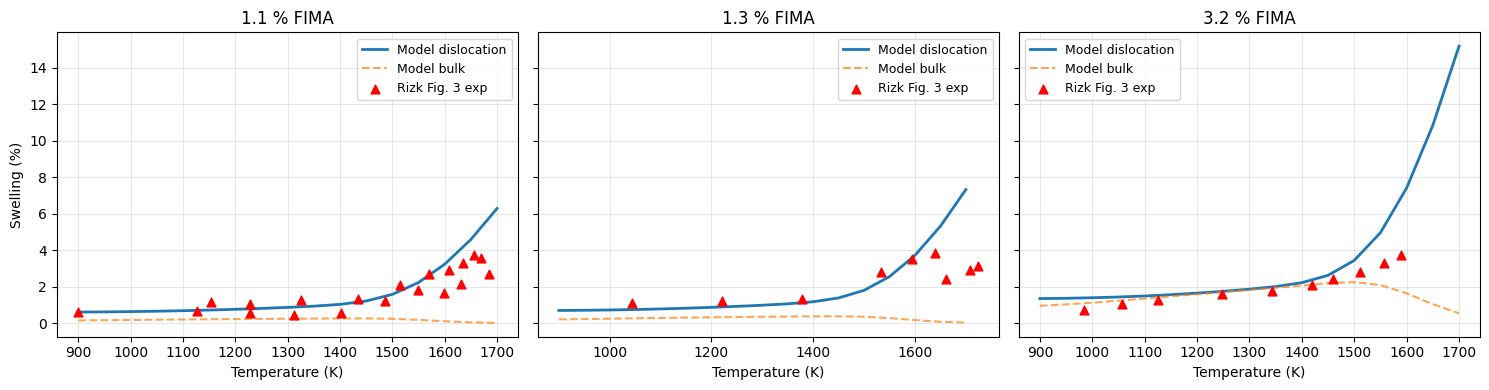

In [4]:
T_grid = np.arange(900, 1750, 50)        # 17 points
burnups = [1.1, 1.3, 3.2]
points = [(float(T), bu) for bu in burnups for T in T_grid]

results = Parallel(n_jobs=-1)(
    delayed(m.run_model_point)(T, bu, cand, DT_H, N_MODES) for (T, bu) in points
)

fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharey=True)
for ax, bu in zip(axes, burnups):
    rows = [r for r in results if abs(r['burnup'] - bu) < 0.01]
    Ts = [r['T'] for r in rows]
    swD = [r['swelling_d_percent'] for r in rows]
    swB = [r['swelling_b_percent'] for r in rows]
    ax.plot(Ts, swD, '-', linewidth=2, label='Model dislocation')
    ax.plot(Ts, swB, '--', linewidth=1.5, alpha=0.7, label='Model bulk')
    exp = [p for p in un_data.EXP_SWELLING_T if abs(p['burnup'] - bu) < 0.01]
    if exp:
        ax.scatter([p['T'] for p in exp], [p['swelling'] for p in exp],
                   color='red', s=40, marker='^', label='Rizk Fig. 3 exp', zorder=5)
    ax.set_xlabel('Temperature (K)')
    ax.set_title(f'{bu} % FIMA')
    ax.grid(alpha=0.3)
    ax.legend(fontsize=9)
axes[0].set_ylabel('Swelling (%)')
plt.tight_layout()
plt.show()


## 4. Dislocation-bubble radius and concentration vs T at 1.3 % FIMA (Rizk Fig. 7 / 8)

With the v14 calibration, N_d should now show the dramatic high-T drop driven by
coalescence and the `gd_line_scale` × `coalescence_d_scale` interplay.


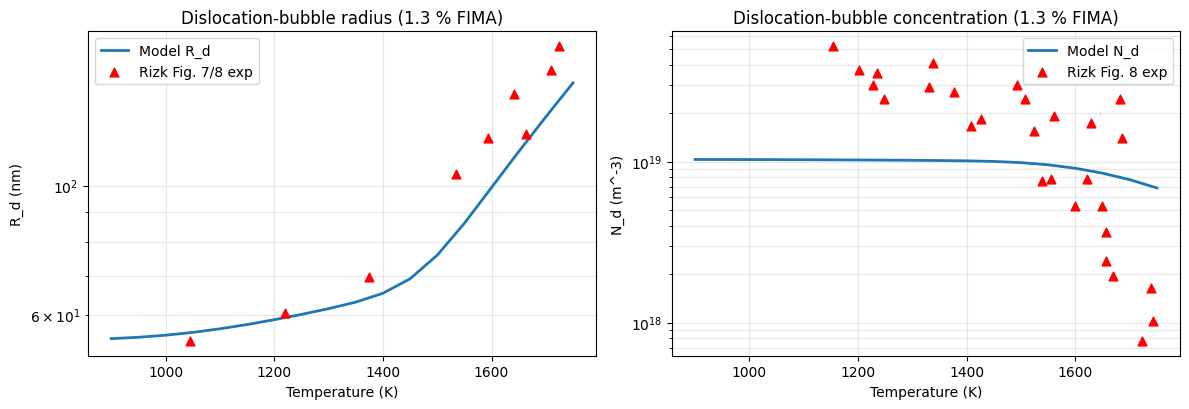

In [5]:
T_grid = np.arange(900, 1800, 50)
results = Parallel(n_jobs=-1)(
    delayed(m.run_model_point)(float(T), 1.3, cand, DT_H, N_MODES) for T in T_grid
)
Ts = [r['T'] for r in results]
Rds = [r['Rd_nm'] for r in results]
Nds = [r['Nd'] for r in results]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4.2))
ax1.plot(Ts, Rds, '-', linewidth=2, label='Model R_d')
ax1.scatter([p['T'] for p in un_data.EXP_RD_T_13], [p['R_nm'] for p in un_data.EXP_RD_T_13],
            color='red', s=40, marker='^', label='Rizk Fig. 7/8 exp', zorder=5)
ax1.set_xlabel('Temperature (K)')
ax1.set_ylabel('R_d (nm)')
ax1.set_yscale('log')
ax1.set_title('Dislocation-bubble radius (1.3 % FIMA)')
ax1.legend()
ax1.grid(alpha=0.3, which='both')

ax2.semilogy(Ts, Nds, '-', linewidth=2, label='Model N_d')
ax2.scatter([p['T'] for p in un_data.EXP_ND_T_13], [p['N'] for p in un_data.EXP_ND_T_13],
            color='red', s=40, marker='^', label='Rizk Fig. 8 exp', zorder=5)
ax2.set_xlabel('Temperature (K)')
ax2.set_ylabel('N_d (m^-3)')
ax2.set_title('Dislocation-bubble concentration (1.3 % FIMA)')
ax2.legend()
ax2.grid(alpha=0.3, which='both')

plt.tight_layout()
plt.show()


## 5. Gas partition vs T (Rizk Fig. 9 style)

Where the produced fission gas lives at 1.3 % FIMA: matrix (in solution),
bulk bubbles, dislocation bubbles, or grain-face (q_gb). With v14's heavy
weighting on the partition score, dislocation gas should dominate at high T.


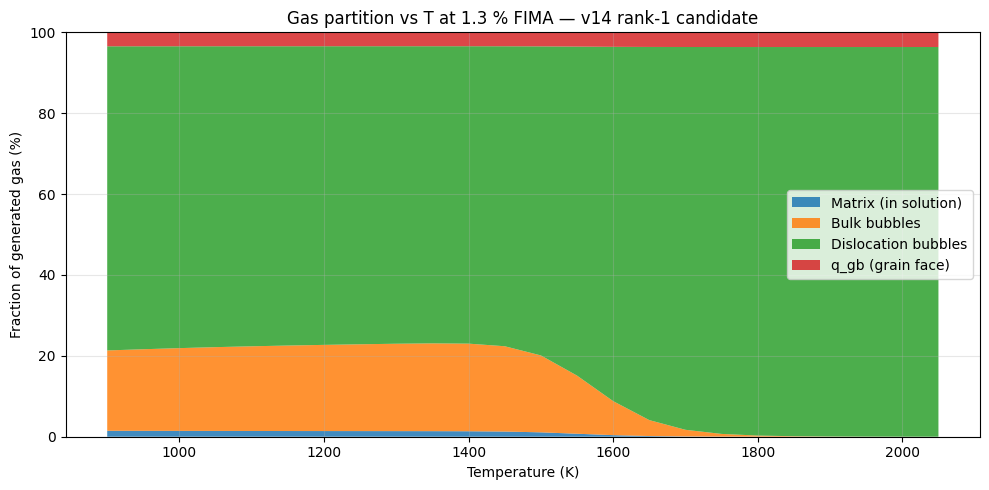

In [6]:
T_grid = np.arange(900, 2100, 50)
results = Parallel(n_jobs=-1)(
    delayed(m.run_model_point)(float(T), 1.3, cand, DT_H, N_MODES) for T in T_grid
)
Ts = [r['T'] for r in results]
matrix = [r['matrix_gas_percent'] for r in results]
bulk = [r['bulk_gas_percent'] for r in results]
disl = [r['dislocation_gas_percent'] for r in results]
qgb = [r['qgb_gas_percent'] for r in results]

fig, ax = plt.subplots(figsize=(10, 5))
ax.stackplot(Ts, matrix, bulk, disl, qgb,
             labels=['Matrix (in solution)', 'Bulk bubbles',
                     'Dislocation bubbles', 'q_gb (grain face)'],
             alpha=0.85)
ax.set_xlabel('Temperature (K)')
ax.set_ylabel('Fraction of generated gas (%)')
ax.set_title('Gas partition vs T at 1.3 % FIMA — v14 rank-1 candidate')
ax.set_ylim(0, 100)
ax.legend(loc='center right')
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()


## 6. v14 best-candidate table

Top-5 candidates from the latest Optuna study (capture_only family).


In [7]:
cols = [c for c in [
    'label', 'score_total', 'f_n', 'K_d', 'rho_d', 'fission_rate',
    'gb_scale', 'gd_bubble_scale', 'gd_line_scale',
    'b_bulk_scale', 'b_dislocation_scale',
    'coalescence_d_scale', 'capture_scale',
    'swD_1p3_1600K', 'Rd_1p3_1600K', 'Nd_1p3_1600K',
] if c in df.columns]
pd.set_option('display.float_format', '{:.3g}'.format)
print(f"Top {min(5, len(df))} v14 candidates (sorted by score_total ascending):\n")
print(df[cols].head(5).to_string(index=False))


Top 5 v14 candidates (sorted by score_total ascending):

                                                label  score_total      f_n      K_d  rho_d  fission_rate  gb_scale  gd_bubble_scale  gd_line_scale  b_bulk_scale  b_dislocation_scale  coalescence_d_scale  capture_scale  swD_1p3_1600K  Rd_1p3_1600K  Nd_1p3_1600K
FINAL_rank1_capture_only_capture_only_v13_trial_00066         2.35 1.81e-07 3.53e+05  3e+13      7.03e+19      1.65           0.0937           5.46         0.243                0.115                0.984          0.247           2.87           101      6.71e+18
FINAL_rank2_capture_only_capture_only_v13_trial_00092         2.41 1.36e-06 3.59e+05  3e+13      7.88e+19     0.381            0.575           2.21        0.0513                0.129                 1.37           2.35           1.51          81.7      6.59e+18
FINAL_rank4_capture_only_capture_only_v13_trial_00061         2.42 1.05e-06 3.63e+05  3e+13      6.96e+19     0.704            0.202           2.39         0

---

End of clean notebook. To rerun cells: Kernel → Restart & Run All.

To regenerate the v14 study from scratch (takes ~minutes per 100 trials):
```bash
cd un_calibration/runners
bash run_v14_rhoSat_qgbStrict_NdAnchors_block.sh 100
```
